              precision    recall  f1-score   support

     Negativ       1.00      0.97      0.98      7141
     Positiv       0.71      0.96      0.81       585

    accuracy                           0.97      7726
   macro avg       0.85      0.96      0.90      7726
weighted avg       0.97      0.97      0.97      7726

[[6908  233]
 [  23  562]]
AUC: 0.9898096582034408
Accuracy:  96.69%
FN-rate:   3.93%  (farliga missade fall)
FP-rate:   3.26%  (onödiga larm)
Sensitivitet:   96.07%  (Sannolikhet att upptäcka ett positivt fall)
Specificitet:   96.74%  (Sannolikhet att korrekt klassificera ett negativt fall negativt)
AUC: 0.9898


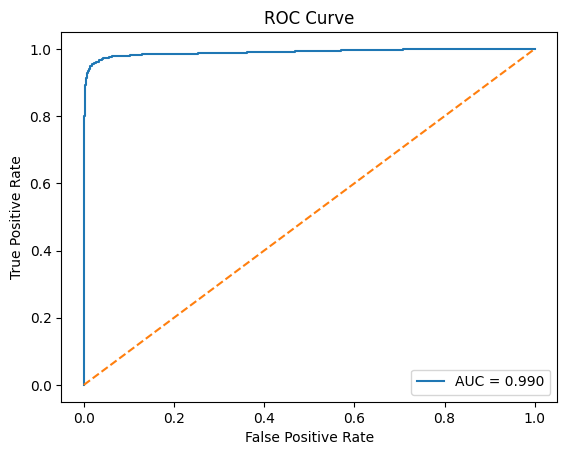

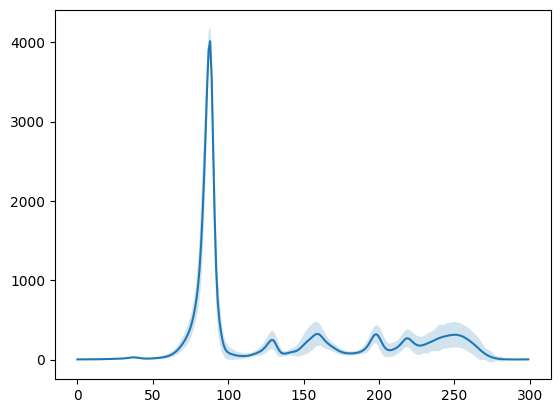

In [ ]:
import duckdb
from functions.analyte import ANALYTES
from networks.cnn_dilated_convolutions import CNNModel
from networks.auto_encoder import AutoencoderModel
from functions.evaluation import evaluate
from functions.full_model import predict_inflammation_and_oligoclonal
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

con = duckdb.connect('../capillary.db')

df = con.execute(""" 
                 SELECT id, age, gender, value,fractions, boundaries,albumin,antitrypsin,orosomukoid,haptoglobin,crp,igg,iga,igm, label, set, interpretation
                 FROM protein_data 
                 WHERE value IS NOT NULL
                 AND analysis IS NOT NULL
                 AND protein_value IS NOT NULL
                 AND observation_nr = 1
                 """).df()

pids = con.execute("SELECT DISTINCT pid FROM protein_data").df()


con.close()

df = df[
    (df['fractions'].apply(len) == 6) &
    (df['boundaries'].apply(len) == 12)
]

protein_cols = [a.col for a in ANALYTES[:8]]  # bara de 8 första
df = df.dropna(subset=protein_cols)
y = df['label']

df = df[df['set'] == 'test']
cnn = CNNModel()
ae = AutoencoderModel()
df = cnn.predict(df)
df = ae.predict(df)
df = predict_inflammation_and_oligoclonal(df)
df = evaluate(df[ (df['label'] == 0 ) | (df['label'] == 1)],threshold=0.2,proportion=70)

stats = pd.DataFrame()
stats['avg'] = np.stack(df['value'].values).mean(axis=0)
stats['std'] = np.stack(df['value'].values).std(axis=0)

avg_line = stats['avg']
stdev = stats['std']
stats.to_csv('statistics_overview.csv')
plt.figure()
plt.plot(range(300),stats['avg'])
plt.fill_between(range(300),avg_line-stdev,avg_line+stdev,alpha=0.2)
plt.show()

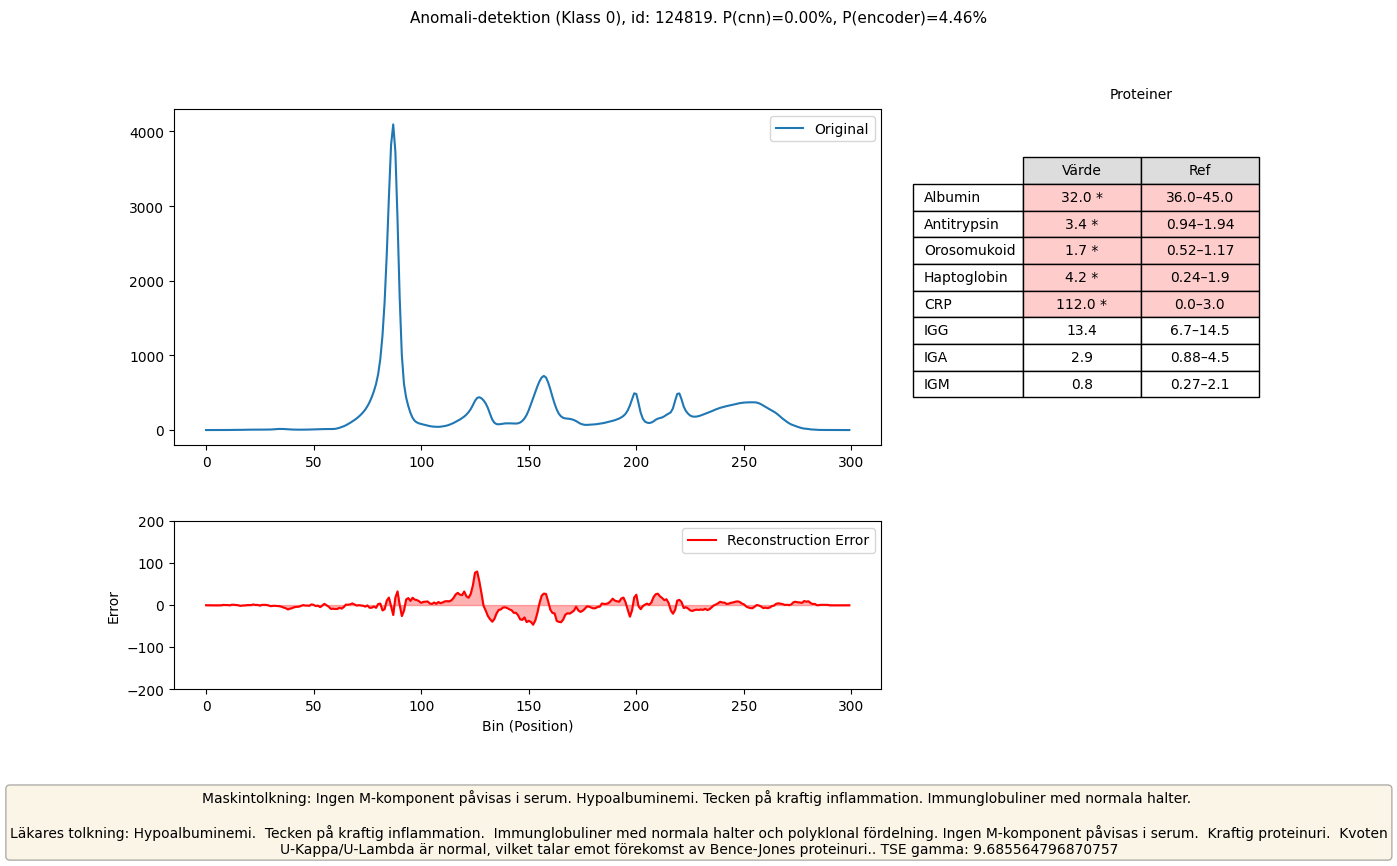

In [40]:
import importlib
import functions.full_model as full_model
importlib.reload(full_model)
from functions.full_model import interpret


#df = evaluate(df[ (df['label'] == 0 ) | (df['label'] == 1)],threshold = 0.15,proportion=50)

#df['prediction'] = ((df['cnn_probability'] > 0.15) | (df['proportion_gamma_region'] > 0.5)).astype(int)

#rows = processed_rows[processed_rows['proportion_gamma_region'] > 0.9].sort_values('proportion_gamma_region',ascending=False)
row = df[(df['cnn_probability'] < 0.1 ) & (df['label'] == 0)].sort_values('cnn_probability',ascending=True).iloc[3,:]

result = interpret(row.to_dict())

